# PyTorch Workflow
let's explore an example PyTorch end-to-end workflow
Resources:
* 

In [10]:
What_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (trainign)",
                      4: "making predictions and evaluting a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

What_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (trainign)',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [11]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for nerual network
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cu128'

## Data (preparing and loading)

Data can be almost anything... in machine learning

* Excel spreadsheet
* Image of any kind
* Videos
* Audio
* DNA 
* Text 

Machine Learning is a game of two parts: 
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation

To showcase this, let's create some *known* data using the linear regression.

In [12]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * x + bias

x[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [13]:
len(x), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

let's create a training and test est with our data

In [14]:
# Create a train/test split
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize"

In [15]:
def plot_prediction(train_data=x_train,
                    train_labels=y_train,
                    test_data=x_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    
    plt.figure(figsize=(10, 7))
    
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
    
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="r", s=4, label="Testing Data")
    
    # Are there predictions?
    if predictions is not None:
        # Plot the predictions if they exists
        plt.scatter(test_data, predictions, c="r", label="Predictions")
        
    # Show legend
    plt.legend(prop={"size":14});

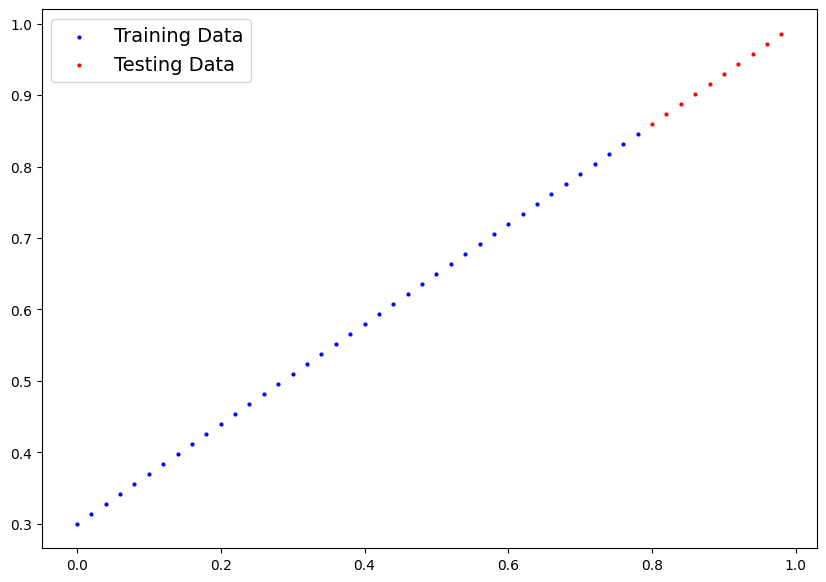

In [16]:
plot_prediction();

## 2. Build Model

Simple first model

python OOP: https://realpython.com/python3-object-oriented-programming/

what our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random value to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through Two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w
2. Backpropagation - https://youtu.be/Ilg3gGewQ5U

In [17]:
# Create a linear regression model class
# almost everything in PyTorch inherits from nn.Module
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1, # <- start with random weight and try to adjust it to the ideal weight
                                               requires_grad=True, # <- can this parameter be updated via graident descent?
                                               dtype=torch.float32)) # <- PyTorch loves the datatype torch.float32
        
        self.bias = nn.Parameter(torch.rand(1, # <- start with random bias and try to adjust it to the ideal bias
                                            requires_grad=True, # <- can this parameter updated via gradient descent?
                                            dtype=torch.float32)) # <- PyTroch loves the datatype toch.float32
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weights* x + self.bias # linear regression formula y = a + bx
        

### PyTorch model building essentials

* `torch.nn` - contains all of buildings for computational graphs(a nerual network can be considered computational graphy)
* `torch.nn.Parameter` - what paraemters should our model try and learn, often a PyTorch layer from `torch.nn` will set these for us
* `torch.nn.Module`  - the base class for all neural network modules, if you subclass it, you should overwrite forward()
* `torch.optim` - this where the optimizers in PyTorch live, they help with gradient descent
* `def forward()` - all nn.Module subclass require you to overwrite forward(), this method defines what happens in the forward computation

see more of these essential via PyTorch cheatsheet = https://www.learnpytorch.io/pytorch_cheatsheet/


### Checking the contents of our PyTorch model

Now we've created a model, lets see what's inside..
So we can check our model parameters or what's inside our model using `.parameters()`

In [18]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [19]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

### Making prediction using ` torch.inference_mode()

To check our model's predective power, let's see how well it predicts `y_test` based on `x_test`.

When we pass the data through our model, it's going to run it through `forward()` method

In [20]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(x_test)
    
# You can do same with torch.no_grad(), however torch.inference_mode() is preferred
# with torch.no_grad():
#     y_preds = model_0(x_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [21]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

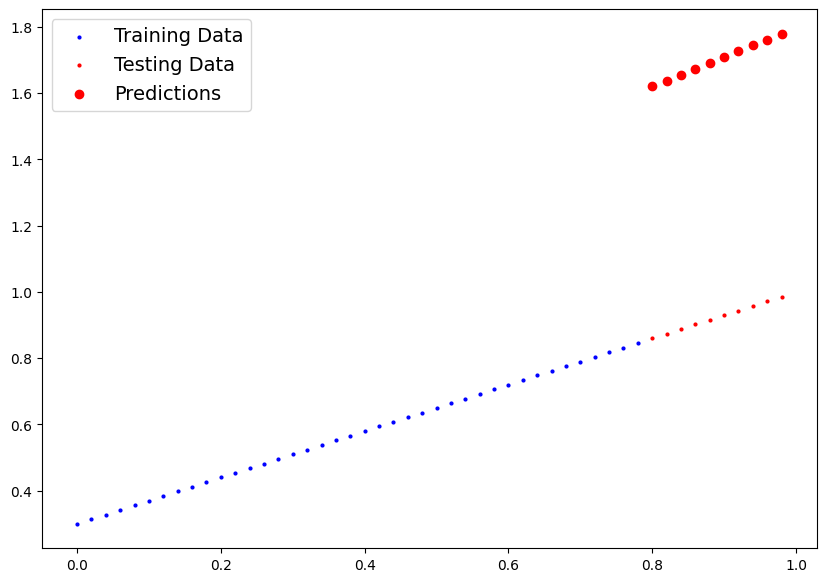

In [22]:
plot_prediction(predictions=y_preds)

## Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation  of the data.

One way to measure how poor or how wrong your model predictions are is to use loos functions.

* **NOTE:** Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss Function:** : A function to measure how wroing your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of model and adjust the model's parameters (e.g. weright & bias in our case) to improve the loss function.

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [23]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [24]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [25]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # lr -> learning rate = possibly the most important hyperparameter you can set